In [35]:
from shared.models import energyscope_original_snapshot_2023
from shared.utils import run_model
from shared.plotting import plot_sankey
from shared.utils import load_snapshot

import matplotlib.pyplot as plt
import pandas as pd

from energyscope.models import Model

# Calculation

In [36]:
from pathlib import Path
import shared.utils as shared_utils

# Définir le chemin absolu exact vers votre dossier "shared"
shared_dir = Path(r"C:\Users\julie\Desktop\EnergyScope-Quebec\shared")

# Redéfinir les dossiers de données et de modèles
shared_utils._DATA_DIR = shared_dir / 'data'
shared_utils._MODEL_DIR = shared_dir / 'model'        # À ajuster en 'models' si le dossier s'appelle ainsi
shared_utils._SCENARIOS_DIR = shared_dir / 'scenarios'  # À ajuster en 'scen' ou 'scenarios' selon votre dossier

# Optionnel : Afficher pour valider le chemin
print("Dossier de données configuré sur :", shared_utils._DATA_DIR)

Dossier de données configuré sur : C:\Users\julie\Desktop\EnergyScope-Quebec\shared\data


In [37]:
model_2050_base_ES = shared_utils.load_snapshot(2050)

## Registre des scénarios

**Le registre est maintenant généré automatiquement** à partir de l'onglet `scenario`
de `scenario_inputs.xlsx` (la table d'assemblage) et des fichiers `.dat`/`.mod`
produits par `Generate_scenarios_clean_sous_scenario.ipynb` dans `data_constraints/`
(nommés `{scenario}.dat` / `{scenario}.mod`).

**Pour ajouter un nouveau scénario**, plus besoin d'écrire de fonction Python ici :
1. Assemble le scénario dans l'onglet `scenario` de `scenario_inputs.xlsx`.
2. Relance `Generate_scenarios_clean_sous_scenario.ipynb` pour générer ses fichiers `.dat`/`.mod`.
3. Réexécute la cellule ci-dessous : le scénario apparaît automatiquement dans `SCENARIOS`.

**`DISPLAYED_SCENARIOS` reste la seule liste à modifier** pour choisir quels scénarios
sont calculés, affichés dans les Sankeys, et comparés dans **toutes** les figures plus bas.

Le scénario `2023` est un cas particulier : il ne passe pas par des fichiers `.dat`/`.mod`
générés, il utilise directement le snapshot de référence `energyscope_original_snapshot_2023`.

`F_Mult_zero.mod` est appliqué automatiquement à tous les scénarios (sauf `2023`), pour l'instant.

In [38]:
import pandas as pd

DATA_CONSTRAINTS = Path(r"C:\Users\julie\Desktop\EnergyScope-Quebec\projects\calculator\scenario_data_constraints")

# <<< à ajuster si scenario_inputs.xlsx n'est pas dans ce dossier >>>
SCENARIO_EXCEL_PATH = Path(r"C:\Users\julie\Desktop\EnergyScope-Quebec\projects\calculator\scenario_generation\scenario_inputs.xlsx")

BASE_SCENARIO_NAME = "2023"  # scénario de référence -> snapshot brut, pas de fichiers générés


def build_scenario_model(scenario_name, data_constraints=DATA_CONSTRAINTS):
    """Construit le Model d'un scénario en empilant automatiquement, sur
    `model_2050_base_ES`, les fichiers générés par
    `Generate_scenarios.ipynb` :
    - `{scenario_name}.dat` (demande + contrainte environnementale)
    - `{scenario_name}.mod` (capacités installées minimales)
    ainsi que `F_Mult_zero.mod`, appliqué à tous les scénarios pour l'instant."""
    files = list(model_2050_base_ES.files)
    files.append(("mod", data_constraints / "F_Mult_zero.mod"))

    dat_path = data_constraints / f"{scenario_name}.dat"
    mod_path = data_constraints / f"{scenario_name}.mod"
    if dat_path.exists():
        files.append(("dat", dat_path))
    if mod_path.exists():
        files.append(("mod", mod_path))

    return Model(files)


def discover_scenarios(excel_path=SCENARIO_EXCEL_PATH, data_constraints=DATA_CONSTRAINTS):
    """Lit l'onglet `scenario` de `scenario_inputs.xlsx` (table d'assemblage) et
    construit automatiquement le registre {nom_scénario: fonction_de_construction}.
    Un scénario listé dans l'Excel mais dont les fichiers .dat/.mod n'ont pas encore
    été générés est ignoré, avec un avertissement (pas de blocage)."""
    scenarios_df = pd.read_excel(excel_path, sheet_name="scenario", index_col=0)
    scenarios_df.index = scenarios_df.index.map(str)

    registry = {}
    for scenario_name in scenarios_df.index:
        if scenario_name == BASE_SCENARIO_NAME:
            registry[scenario_name] = lambda: energyscope_original_snapshot_2023
            continue

        dat_path = data_constraints / f"{scenario_name}.dat"
        mod_path = data_constraints / f"{scenario_name}.mod"
        if not dat_path.exists() and not mod_path.exists():
            print(f"[avertissement] '{scenario_name}' : aucun fichier .dat/.mod trouvé dans "
                  f"'{data_constraints}' -- ignoré (relance Generate_scenarios.ipynb)")
            continue

        # name=scenario_name : capture par valeur pour éviter le piège de la closure tardive
        registry[scenario_name] = (lambda name=scenario_name, dc=data_constraints: build_scenario_model(name, dc))

    return registry


SCENARIOS = discover_scenarios()
print("Scénarios disponibles :", list(SCENARIOS.keys()))


Scénarios disponibles : ['2023', 'MEIE_2050', 'MEIE_2050_HD', 'MEIE_2050_no_CCS', 'MEIE_2050_nuclear']


In [40]:
# <<< LA SEULE LIGNE À MODIFIER POUR CHANGER LES SCÉNARIOS CALCULÉS ET AFFICHÉS >>>
# Les noms doivent correspondre exactement à ceux de l'onglet 'scenario' de scenario_inputs.xlsx
# (voir SCENARIOS.keys() ci-dessus pour la liste disponible).
DISPLAYED_SCENARIOS = ['2023', 'MEIE_2050', 'MEIE_2050_HD', 'MEIE_2050_no_CCS', 'MEIE_2050_nuclear']


## Calcul des scénarios

Construit et résout le modèle pour chaque scénario de `DISPLAYED_SCENARIOS`.
`results[nom_scénario]` remplace les variables séparées (`results_2023`, `results_2050`, ...) —
tout le reste du notebook va chercher les résultats dans ce dictionnaire.

In [41]:
models = {}
results = {}
for name in DISPLAYED_SCENARIOS:
    print(f"\n--- Calcul du scénario '{name}' ---")
    models[name] = SCENARIOS[name]()
    results[name] = run_model(models[name])


--- Calcul du scénario '2023' ---
Gurobi 13.0.2: 
--- Calcul du scénario 'MEIE_2050' ---
Error:
	C:\Users\julie\Desktop\EnergyScope-Quebec\projects\calculator\scenario_data_constraints\MEIE_2050.dat
	line 3 offset 58
	syntax error
	context:  let  >>> ccs_capture_limit  <<< := 15.00 ;

For support/feedback go to https://discuss.ampl.com or e-mail <support@ampl.com>



AMPLException: C:\Users\julie\Desktop\EnergyScope-Quebec\projects\calculator\scenario_data_constraints\MEIE_2050.dat
line 3 offset 58
syntax error
context:  let  >>> ccs_capture_limit  <<< := 15.00 ;

## Sankey — un diagramme par scénario affiché

In [7]:
for name in DISPLAYED_SCENARIOS:
    print(f"=== {name} ===")
    fig = plot_sankey(results[name])
    if fig is not None:
        display(fig)

=== 2023 ===


=== MEIE_2050 ===


=== MEIE_2050_HD ===


=== MEIE_2050_no_CCS ===


# Results comparison

**Fonction générique** : calcule `generator_fn(results[s])` pour chaque scénario de
`DISPLAYED_SCENARIOS`, puis appelle `plot_fn(list_df, list_scenarios, **kwargs)`. Toutes les
figures ci-dessous n'ont donc plus qu'une ligne — elles suivent automatiquement
`DISPLAYED_SCENARIOS` défini plus haut.

In [8]:
def compare_across_scenarios(generator_fn, plot_fn, scenarios=None, **plot_kwargs):
    """Calcule generator_fn(results[s]) pour chaque scénario (par défaut DISPLAYED_SCENARIOS),
    puis appelle plot_fn(list_df, list_scenarios, **plot_kwargs)."""
    scenarios = list(scenarios) if scenarios is not None else DISPLAYED_SCENARIOS
    list_df = [generator_fn(results[s]) for s in scenarios]
    return plot_fn(list_df, scenarios, **plot_kwargs)

## Demands

In [12]:
def generate_energy_all_sectors(results_data, titre="Consommation d\'énergie"):
    """Calcule et retourne le DataFrame de la consommation par secteur."""
    # 1) Configuration des patterns
    ENERGY_LAYER_PAT = r"^(?:ELECTRICITY_|GASOLINE|DIESEL|JETFUEL|HFO|LFO|PROPANE|NG_|SNG_|H2_|METHANOL|BIO_|ETHANOL)"
    PASSENGER_KEYS = r"(?:CAR|BUS|COACH|TRAMWAY|SCHOOLBUS|TRAIN|PLANE|SUV)"
    FREIGHT_KEYS = r"(?:TRUCK|FREIGHT|LCV|SEMI|BULK|CONTAINER|TANKER)"

    # 2) Secteurs Hors Transport
    demand = results_data.parameters["end_uses_demand_year"]["end_uses_demand_year"]
    sectors = ["HOUSEHOLDS", "SERVICES", "INDUSTRY", "AGRICULTURE"]
    s_sector = demand.unstack(level=1)[sectors].sum()
    s_sector.index = ["Résidentiel", "Services", "Industrie", "Agriculture"]

    # 3) Transports
    ap = results_data.variables["Annual_Prod"]["Annual_Prod"]
    lio = results_data.parameters["layers_in_out"]["layers_in_out"]
    lio_inputs = lio[lio < 0].abs()
    lio_energy = lio_inputs[lio_inputs.index.get_level_values(1).str.contains(ENERGY_LAYER_PAT, regex=True, case=False)]
    energy_by_tech = lio_energy.mul(ap, level="index0").groupby(level="index0").sum()

    is_passenger = energy_by_tech.index.str.contains(PASSENGER_KEYS, regex=True, case=False)
    is_freight = energy_by_tech.index.str.contains(FREIGHT_KEYS, regex=True, case=False)
    s_sector["Transport passagers"] = energy_by_tech[is_passenger].sum()
    s_sector["Transport fret"] = energy_by_tech[is_freight].sum()

    # 4) Création du DataFrame final (conversion GWh -> TWh et arrondi)
    df_final = (s_sector / 1000).round(1).to_frame(titre)
    return df_final

In [13]:
def plot_energy_comparison_stacked_bar(list_df_demands, list_scenarios):
    """Génère un graphique stacked bar pour comparer plusieurs scénarios.

    list_df_demands : liste de DataFrames (ex: [df_2020, df_2030, df_2050])
    list_scenarios : liste de strings pour nommer les colonnes (ex: ['2020',
    '2030', '2050'])
    """
    df_compare = pd.DataFrame()

    # 1) Renommer et combiner chaque scénario par sa première colonne
    for df, scenario in zip(list_df_demands, list_scenarios):
        nom_origine = df.columns[0]
        # On extrait uniquement la colonne de données brute (sans la colonne %)
        df_compare[scenario] = df[nom_origine]

    # 2) Génération du Stacked Bar Plot (On transpose .T pour avoir 1 barre par scénario)
    ax = df_compare.T.plot(kind="bar", stacked=True, figsize=(8, 6))

    plt.title("Comparaison de la demande d\'énergie")
    plt.ylabel("Énergie [TWh]")
    plt.xlabel("Scénarios")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return df_compare

In [14]:
compare_across_scenarios(generate_energy_all_sectors, plot_energy_comparison_stacked_bar)

NameError: name 'compare_across_scenarios' is not defined

### Transport - Passenger

In [15]:
def generate_demand_passenger_transport(results_data, col_titre="Transport Passagers (TWh)"):
    """Calcule la consommation d\'énergie du transport passager (TWh) par type de véhicule."""

    # 1) Couches d'énergie d'entrée
    ENERGY_LAYER_PAT = (
        r"^(?:ELECTRICITY|GASOLINE|DIESEL|JETFUEL|HFO|LFO|PROPANE|"
        r"NG_|SNG_|H2_|METHANOL|BIO_|ETHANOL)"
    )

    CATEGORIES = {
        # Tout ce qui commence par CAR_EV ou contient _EV_ / _PHEV_
        "Voitures Électriques": r"^CAR_(?:EV|PHEV)(?:_|$)",

        # Tout ce qui commence par CAR_ mais qui N'EST PAS EV ou PHEV
        "Voitures Thermiques & Hybrides": r"^CAR_(?!(?:EV|PHEV)(?:_|$))",

        # Tout ce qui commence par SUV_EV ou contient _EV_ / _PHEV_
        "SUV Électriques": r"^SUV_(?:EV|PHEV)(?:_|$)",

        # Tout ce qui commence par SUV_ mais N'EST PAS EV ou PHEV
        "SUV Thermiques & Hybrides": r"^SUV_(?!(?:EV|PHEV)(?:_|$))",

        # Autres modes
        "Transport Public (Bus/Tram)": r"(?:BUS|COACH|TRAMWAY|SCHOOLBUS)",
        "Trains": r"TRAIN",
        "Avions": r"PLANE"
    }

    # 2) Extraction de la consommation d'énergie
    ap = results_data.variables["Annual_Prod"]["Annual_Prod"]
    lio = results_data.parameters["layers_in_out"]["layers_in_out"]

    lio_inputs = lio[lio < 0].abs()

    # Filtre sur les couches énergétiques (index level 1)
    is_energy_layer = lio_inputs.index.get_level_values(1).str.contains(ENERGY_LAYER_PAT, regex=True, case=False)
    lio_energy = lio_inputs[is_energy_layer]

    # Multiplication par Annual_Prod et somme par technologie (index level 0)
    energy_by_tech = lio_energy.mul(ap, level=0).groupby(level=0).sum()

    # 3) Ventilation par catégorie
    passenger_energy = {}
    for cat_name, pattern in CATEGORIES.items():
        is_cat = energy_by_tech.index.str.contains(pattern, regex=True, case=False)
        passenger_energy[cat_name] = energy_by_tech[is_cat].sum()

    # 4) Conversion GWh -> TWh
    s_passenger = pd.Series(passenger_energy) / 1000.0

    # 5) Construction du DataFrame final
    df_final = s_passenger.to_frame(name=col_titre)
    df_final.loc["Total", col_titre] = s_passenger.sum()
    df_final[col_titre] = df_final[col_titre].round(1)

    return df_final

In [16]:
def plot_passenger_energy_comparison_stacked_bar(list_df_passengers, list_scenarios, title="Comparaison de la demande d\'énergie - Transport Passagers"):
    """
    Trace un diagramme en barres empilées (stacked bar plot) pour la demande en énergie
    du transport passager et affiche le DataFrame récapitulatif (1 décimale) sous la figure.
    """
    # 1. Combinaison des DataFrames
    combined_data = {}
    for df, scenario in zip(list_df_passengers, list_scenarios):
        col_name = df.columns[0]
        # Exclure la ligne 'Total' pour le graphique empilé
        df_clean = df.drop(index="Total", errors="ignore")
        combined_data[scenario] = df_clean[col_name]

    # Transposer : lignes = scénarios (axe X), colonnes = catégories
    df_plot = pd.DataFrame(combined_data).T

    # 2. Ordre explicite des catégories pour garantir qu'elles figurent toutes dans la légende
    categories_order = [
        "Voitures Thermiques & Hybrides",
        "Voitures Électriques",
        "SUV Thermiques & Hybrides",
        "SUV Électriques",
        "Transport Public (Bus/Tram)",
        "Trains",
        "Avions"
    ]

    # Réorganiser les colonnes présentées
    existing_cols = [col for col in categories_order if col in df_plot.columns]
    df_plot = df_plot[existing_cols]

    # 3. Dictionnaire de couleurs harmonisées
    color_map = {
        "Voitures Thermiques & Hybrides": "#1f77b4",  # Bleu foncé
        "Voitures Électriques": "#6baed6",             # Bleu clair
        "SUV Thermiques & Hybrides": "#d62728",       # Rouge / Brique
        "SUV Électriques": "#ff9896",                  # Rose / Rouge clair
        "Transport Public (Bus/Tram)": "#2ca02c",     # Vert
        "Trains": "#9467bd",                          # Violet
        "Avions": "#ff7f0e"                           # Orange
    }

    colors = [color_map.get(cat, "#7f7f7f") for cat in df_plot.columns]

    # 4. Création du graphique
    fig, ax = plt.subplots(figsize=(10, 6))

    bars = df_plot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=colors,
        edgecolor="white",
        linewidth=0.8,
        width=0.45
    )

    # Personnalisation du graphique
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    ax.set_ylabel("Demande d\'énergie (TWh)", fontsize=11)
    ax.set_xlabel("Scénario", fontsize=11)

    plt.xticks(rotation=0, fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # Légende décalée à droite
    ax.legend(title="Catégories", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

    plt.tight_layout()
    plt.show()

    # 5. Affichage du DataFrame de synthèse (Formaté à 1 seule décimale)
    df_display = df_plot.copy().T  # Format : lignes = catégories, colonnes = scénarios
    df_display.loc["Total"] = df_display.sum()

    print("\n=== Données affichées dans le graphique (TWh) ===")
    print(df_display.map(lambda x: f"{x:.1f}").to_string())

In [17]:
compare_across_scenarios(generate_demand_passenger_transport, plot_passenger_energy_comparison_stacked_bar)

NameError: name 'compare_across_scenarios' is not defined

### Transport - Freight

In [18]:
def generate_demand_freight_transport(results_data, col_titre="Transport Fret (TWh)"):
    """Calcule la consommation d\'énergie du transport de fret (TWh) par type de véhicule."""
    # 1) Configuration des patterns
    ENERGY_LAYER_PAT = r"^(?:ELECTRICITY_|GASOLINE|DIESEL|JETFUEL|HFO|LFO|PROPANE|NG_|SNG_|H2_|METHANOL|BIO_|ETHANOL)"
    CATEGORIES = {
        "Camions légers": r"LCV",
        "Camions & Poids lourds": r"(?:TRUCK|SEMI)",
        "Trains Fret": r"FREIGHT",
        "Bateaux & Navires": r"(?:BULK|CONTAINER|TANKER)"
    }

    # 2) Extraction et calcul de l'énergie par technologie (GWh)
    ap = results_data.variables["Annual_Prod"]["Annual_Prod"]
    lio = results_data.parameters["layers_in_out"]["layers_in_out"]
    lio_inputs = lio[lio < 0].abs()
    lio_energy = lio_inputs[lio_inputs.index.get_level_values(1).str.contains(ENERGY_LAYER_PAT, regex=True, case=False)]
    energy_by_tech = lio_energy.mul(ap, level="index0").groupby(level="index0").sum()

    # 3) Ventilation par catégorie de transport fret
    freight_energy = {}
    for cat_name, pattern in CATEGORIES.items():
        is_cat = energy_by_tech.index.str.contains(pattern, regex=True, case=False)
        freight_energy[cat_name] = energy_by_tech[is_cat].sum()

    # 4) Création du DataFrame final en TWh (sans ligne total)
    df_freight = pd.Series(freight_energy) / 1000
    df_final = pd.DataFrame(index=list(CATEGORIES.keys()))
    df_final[col_titre] = list(df_freight.round(1))

    return df_final

In [19]:
def plot_freight_energy_comparison_stacked_bar(list_df_freight, list_scenarios):
    """Génère un graphique stacked bar pour comparer la consommation d\'énergie
    du transport de fret sur plusieurs scénarios.

    list_df_freight : liste de DataFrames générés par generate_demand_freight_transport
    list_scenarios : liste de strings pour nommer les colonnes (ex: ['2020', '2030', '2050'])
    """
    df_compare = pd.DataFrame()

    # 1) Renommer et combiner chaque scénario par sa première colonne
    for df, scenario in zip(list_df_freight, list_scenarios):
        nom_origine = df.columns[0]
        df_compare[scenario] = df[nom_origine]

    # 2) Génération du Stacked Bar Plot (.T pour avoir 1 barre par scénario)
    ax = df_compare.T.plot(kind="bar", stacked=True, figsize=(8, 6))

    plt.title("Comparaison de la consommation d\'énergie - Transport Fret")
    plt.ylabel("Énergie [TWh]")
    plt.xlabel("Scénarios")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return df_compare

In [20]:
compare_across_scenarios(generate_demand_freight_transport, plot_freight_energy_comparison_stacked_bar)

NameError: name 'compare_across_scenarios' is not defined

## Ressources

In [21]:
# Dictionnaire de correspondance par défaut (à adapter selon tes noms exacts de RES_)
DEFAULT_RESOURCE_MAPPING = {
    "DIESEL": "Diesel",
    "GASOLINE": "Essence",
    "NG_EHP": "Gaz Naturel",
    "COAL": "Charbon",
    "PROPANE": "Propane",
    "LFO": "Mazout léger (LFO)",
    "HFO": "Mazout lourd (HFO)",
    "JETFUEL": "Jetfuel",
    "BIOMASS_FORESTRY_LEFTOVER1": "Biomasse forestière",
    "BIOMASS_FORESTRY_LEFTOVER2": "Biomasse forestière - 2e",
    "BIOMASS_WASTE_BUILDING": "Bois CRD",
    "ELECTRICITY_HV": "Électricité Importée",
    "H2": "Hydrogène",
    "URANIUM": "Uranium"
}

def generate_filtered_resources(results_data, rename_dict=DEFAULT_RESOURCE_MAPPING):
    """Filtre, trie, renomme et retourne les ressources actives en excluant certaines technologies."""
    # 1. Conversion en DataFrame
    df_res = pd.DataFrame(results_data.variables["Annual_Res"])

    # 2. Filtrer pour exclure les lignes égales à 0
    df_res_filtered = df_res[df_res.iloc[:, 0] != 0].copy()

    # 3. Exclure les ressources spécifiques
    exclude_list = ["RES_HYDRO", "RES_WIND_ONSHORE", "RES_SOLAR", "ELECTRICITY_EHV", "CO2_E"]
    df_res_filtered = df_res_filtered[~df_res_filtered.index.isin(exclude_list)]

    # 4. Renommer les ressources via le dictionnaire
    if rename_dict:
        # Renomme les clés trouvées, garde le nom d'origine si non présent dans le dictionnaire
        df_res_filtered.index = df_res_filtered.index.map(lambda x: rename_dict.get(x, x))

    # 5. Trier en ordre décroissant
    df_res_sorted = df_res_filtered.sort_values(by=df_res_filtered.columns[0], ascending=False)

    return df_res_sorted

In [22]:
def plot_resources_comparison(list_df_res, list_scenarios, titre_graphique="Comparaison des ressources énergétiques", convert_to_twh=True):
    """
    Génère un graphique en barres pour comparer les ressources et affiche
    le DataFrame récapitulatif (1 décimale) sous la figure.
    """
    df_compare = pd.DataFrame()

    # 1) Combinaison des DataFrames pré-filtrés
    for df, scenario in zip(list_df_res, list_scenarios):
        nom_origine = df.columns[0]
        df_compare[scenario] = df[nom_origine]

    # Remplacement des NaN par 0
    df_compare = df_compare.fillna(0)

    # Conversion GWh -> TWh si demandé (pour cohérence avec les transports)
    if convert_to_twh:
        df_compare = df_compare / 1000.0
        unit_label = "Ressources (TWh)"
    else:
        unit_label = "Ressources (GWh)"

    # Tri basé sur le premier scénario
    df_compare = df_compare.sort_values(by=list_scenarios[0], ascending=False)

    # 2) Génération du graphique
    fig, ax = plt.subplots(figsize=(10, 6))
    df_compare.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")

    plt.title(titre_graphique, fontsize=13, fontweight="bold", pad=15)
    plt.xlabel("Ressources", fontsize=11)
    plt.ylabel(unit_label, fontsize=11)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend(title="Scénarios", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # 3) Affichage du DataFrame de synthèse (1 seule décimale)
    df_display = df_compare.copy()
    df_display.loc["Total"] = df_display.sum()

    print(f"\n=== Données affichées dans le graphique ({'TWh' if convert_to_twh else 'GWh'}) ===")
    print(df_display.map(lambda x: f"{x:.1f}").to_string())

In [23]:
compare_across_scenarios(generate_filtered_resources, plot_resources_comparison)

NameError: name 'compare_across_scenarios' is not defined

In [24]:
def generate_annual_production_elec_df(results):
    """
    Extrait la valeur float de EHV_GRID et la retourne sous forme de DataFrame.
    """
    val_elec = results.variables['Annual_Prod']['Annual_Prod'].loc['EHV_GRID']
    return pd.DataFrame({'EHV_GRID': [val_elec]}, index=['EHV_GRID'])

In [25]:
def plot_resources_stacked(
    list_df_ressources,
    list_df_annual_prod_elec,
    list_scenarios,
    convert_to_twh=True,
):
    """Regroupe les ressources et y ajoute l'électricité de annual_prod pour afficher

    un graphique en barres empilées par scénario.
    """
    # 1) Dictionnaire de regroupement
    mapping_dict = {
        # Fossiles
        "Gaz Naturel": "Gaz naturel",
        "Essence": "Fossiles",
        "Diesel": "Fossiles",
        "Mazout léger (LFO)": "Fossiles",
        "Mazout lourd (HFO)": "Fossiles",
        "Jetfuel": "Fossiles",
        "Charbon": "Fossiles",
        "Propane": "Fossiles",
        # Biomasse
        "Biomasse forestière": "Biomasse",
        "Biomasse forestière - 2e": "Biomasse",
        "Bois CRD": "Biomasse",
        "BIOMASS_WASTE_PAPER_FABRIC": "Biomasse",
        "BIOMASS_WASTE_ORGANIC": "Biomasse",
        "BIOMASS_WASTE_MUNICIPAL": "Biomasse",
        "BIOMASS_FORESTRY_RESIDUAL": "Biomasse",
        "BIOMASS_AGRICULTURE_DEJECTION" : "Biomasse",
        "BIOMASS_FORESTRY_UNEXPLOITED"  : "Biomasse",
        "BIOMASS_WASTE_PAPER" : "Biomasse",
    }

    records = []

    # 2) Agrégation des données par scénario
    for df_res, df_elec, scenario in zip(
        list_df_ressources, list_df_annual_prod_elec, list_scenarios
    ):
        # Correction : Initialisation explicite de 'Gaz naturel' pour éviter KeyError
        row = {
            "Scénario": scenario,
            "Électricité": 0.0,
            "Gaz naturel": 0.0,
            "Fossiles": 0.0,
            "Biomasse": 0.0,
            "Autre": 0.0,
        }

        # Ressources
        col_res = df_res.columns[0]
        for res_name, val in df_res[col_res].items():
            cat = mapping_dict.get(res_name, "Autre")
            row[cat] += val

        # Électricité
        col_elec = df_elec.columns[0]
        row["Électricité"] += df_elec[col_elec].sum()

        records.append(row)

    # Création du DataFrame récapitulatif
    df_combinee = pd.DataFrame(records).set_index("Scénario")

    # Conversion GWh -> TWh
    if convert_to_twh:
        df_combinee = df_combinee / 1000.0
        unit_label = "Consommation (TWh)"
    else:
        unit_label = "Consommation (GWh)"

    # Ordre des catégories dans les barres
    ordre_cat = ["Électricité", "Gaz naturel", "Fossiles", "Biomasse", "Autre"]
    cols_existantes = [c for c in ordre_cat if c in df_combinee.columns]
    df_plot = df_combinee[cols_existantes]

    # 3) Création du graphique
    fig, ax = plt.subplots(figsize=(8, 5))
    df_plot.plot(
        kind="bar", stacked=True, ax=ax, width=0.45, edgecolor="white"
    )

    plt.title(
        "Répartition des ressources et de l\'électricité par scénario",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Scénarios", fontsize=10)
    plt.ylabel(unit_label, fontsize=10)
    plt.xticks(rotation=0, fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # Légende inversée
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1],
        labels[::-1],
        title="Catégories",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()

    # 4) Tableau récapitulatif (1 seule décimale)
    df_tableau = df_plot.T
    df_tableau.loc["Total"] = df_tableau.sum()
    print(f"\n=== Bilan ({'TWh' if convert_to_twh else 'GWh'}) ===")
    print(df_tableau.map(lambda x: f"{x:.1f}").to_string())

`plot_resources_stacked` prend deux listes de DataFrames (ressources + électricité) —
ne rentre pas dans le moule à un seul générateur de `compare_across_scenarios`, donc on
construit les deux listes directement à partir de `DISPLAYED_SCENARIOS` (toujours une seule
source de vérité, juste pas via le helper générique).

In [26]:
list_df_ressources = [generate_filtered_resources(results[s]) for s in DISPLAYED_SCENARIOS]
list_df_annual_prod_elec = [generate_annual_production_elec_df(results[s]) for s in DISPLAYED_SCENARIOS]
plot_resources_stacked(list_df_ressources, list_df_annual_prod_elec, DISPLAYED_SCENARIOS)

KeyError: 'MEIE_2050'

## Production

In [27]:
def generate_tech_capacity_df(results_data, col_titre="Puissance (GW)"):
    """Crée un DataFrame à partir de la variable F_Mult en agrégeant les technologies
    selon TECH_LABELS, en ajoutant les importations depuis 'Annual_Res',
    et en excluant la colonne 'Run' ainsi que les valeurs à 0.
    """
    TECH_LABELS = {
        "GAS_CENTRAL": "Centrale - Gaz",
        "CCGT": "Centrale - Gaz",
        "HYDRO_DAM": "Hydro - Barrage",
        "NEW_HYDRO_DAM": "Hydro - Barrage",
        "HYDRO_RIVER": "Hydro - Rivières",
        "PV_ROOF": "PV",
        "PV_GROUND": "PV",
        "WIND_ONSHORE": "Éolien",
        "WIND_OFFSHORE": "Éolien",
        "NUCLEAR": "Nucléaire"
    }

    # 1) Extraction de la variable F_Mult sous forme de DataFrame
    df_fmult = pd.DataFrame(results_data.variables["F_Mult"])

    # 2) Supprimer la colonne 'Run' si elle existe
    if "Run" in df_fmult.columns:
        df_fmult = df_fmult.drop(columns=["Run"])

    # 3) Filtrer pour ne garder que les technologies définies dans TECH_LABELS
    df_filtered = df_fmult[df_fmult.index.isin(TECH_LABELS.keys())].copy()

    # 4) Remplacer les index par les labels simplifiés
    df_filtered.index = df_filtered.index.map(TECH_LABELS)

    # 5) Sommer les technologies qui ont désormais le même label
    df_grouped = df_filtered.groupby(level=0).sum()

    # 6) Récupérer la valeur d'importation depuis Annual_Res
    try:
        df_res = pd.DataFrame(results_data.variables["Annual_Res"])
        if "Run" in df_res.columns:
            df_res = df_res.drop(columns=["Run"])

        # Extraction de la valeur pour ELECTRICITY_EHV (première colonne)
        import_val = df_res.loc["ELECTRICITY_EHV"].iloc[0]/(365*24)
        # Ajout direct de la ligne "Importations"
        df_grouped.loc["Importations*"] = import_val
    except KeyError:
        # Au cas où ELECTRICITY_EHV n'existe pas dans Annual_Res
        pass

    # 7) Filtrer pour exclure les lignes égales à 0 et trier par ordre décroissant
    df_grouped = df_grouped[df_grouped.iloc[:, 0] != 0]
    df_sorted = df_grouped.sort_values(by=df_grouped.columns[0], ascending=False)

    # 8) Renommer de façon sécurisée la première colonne
    df_sorted = df_sorted.rename(columns={df_sorted.columns[0]: col_titre})

    return df_sorted

In [28]:
def plot_tech_capacity_comparison_stacked_bar(list_df_techs, list_scenarios, titre_graphique="Comparaison des capacités installées et importations"):
    # 1) Combiner tous les DataFrames en tenant compte de l'union des index (toutes les technologies)
    series_list = []
    for df, scenario in zip(list_df_techs, list_scenarios):
        nom_origine = df.columns[0]
        series_list.append(df[nom_origine].rename(scenario))

    df_compare = pd.concat(series_list, axis=1)  # union des index par défaut (outer join)
    df_compare = df_compare.fillna(0)

    # 2) Génération du Stacked Bar Plot (.T pour avoir 1 barre par scénario)
    ax = df_compare.T.plot(kind="bar", stacked=True, figsize=(8, 6))

    plt.title(titre_graphique)
    plt.ylabel('Capacité [MW]')
    plt.xlabel("Scénarios")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return df_compare

In [29]:
compare_across_scenarios(generate_tech_capacity_df, plot_tech_capacity_comparison_stacked_bar)

NameError: name 'compare_across_scenarios' is not defined

### CO2

In [28]:
def generate_gwp_by_category(results_data, col_titre="GWP (Mt CO2-eq)"):
    """Calcule le GWP total (sommé sur index1) pour chaque catégorie CO2
    (CO2_A, CO2_C, CO2_S, CO2_E)."""
    categories = ["CO2_A", "CO2_C", "CO2_S", "CO2_E"]
    gwp = results_data.variables["GWP"]["GWP"]

    totals = {}
    for cat in categories:
        if cat in gwp.index.get_level_values(0):
            totals[cat] = gwp.loc[cat].sum()
        else:
            totals[cat] = 0.0

    return pd.DataFrame({col_titre: totals})

In [29]:
def plot_gwp_comparison_subplots(list_df_gwp, list_scenarios, titre_graphique="Comparaison du GWP par catégorie CO2"):
    """Trace 4 subplots (2x2) — un par catégorie CO2 (CO2_A, CO2_C, CO2_S, CO2_E) —
    comparant la valeur de chaque scénario, et affiche le DataFrame récapitulatif."""
    df_compare = pd.DataFrame()
    for df, scenario in zip(list_df_gwp, list_scenarios):
        nom_origine = df.columns[0]
        df_compare[scenario] = df[nom_origine]

    categories = ["CO2_A", "CO2_C", "CO2_S", "CO2_E"]
    titles_map = {
        "CO2_A": "CO2_A",
        "CO2_C": "CO2_C",
        "CO2_S": "CO2_S",
        "CO2_E": "CO2_E",
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()

    for ax, cat in zip(axes, categories):
        if cat in df_compare.index:
            df_compare.loc[cat].plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
        ax.set_title(titles_map.get(cat, cat), fontsize=11, fontweight="bold")
        ax.set_ylabel("GWP [Mt CO2-eq]", fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0, labelsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    fig.suptitle(titre_graphique, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\n=== Données affichées dans le graphique (Mt CO2-eq) ===")

    return df_compare

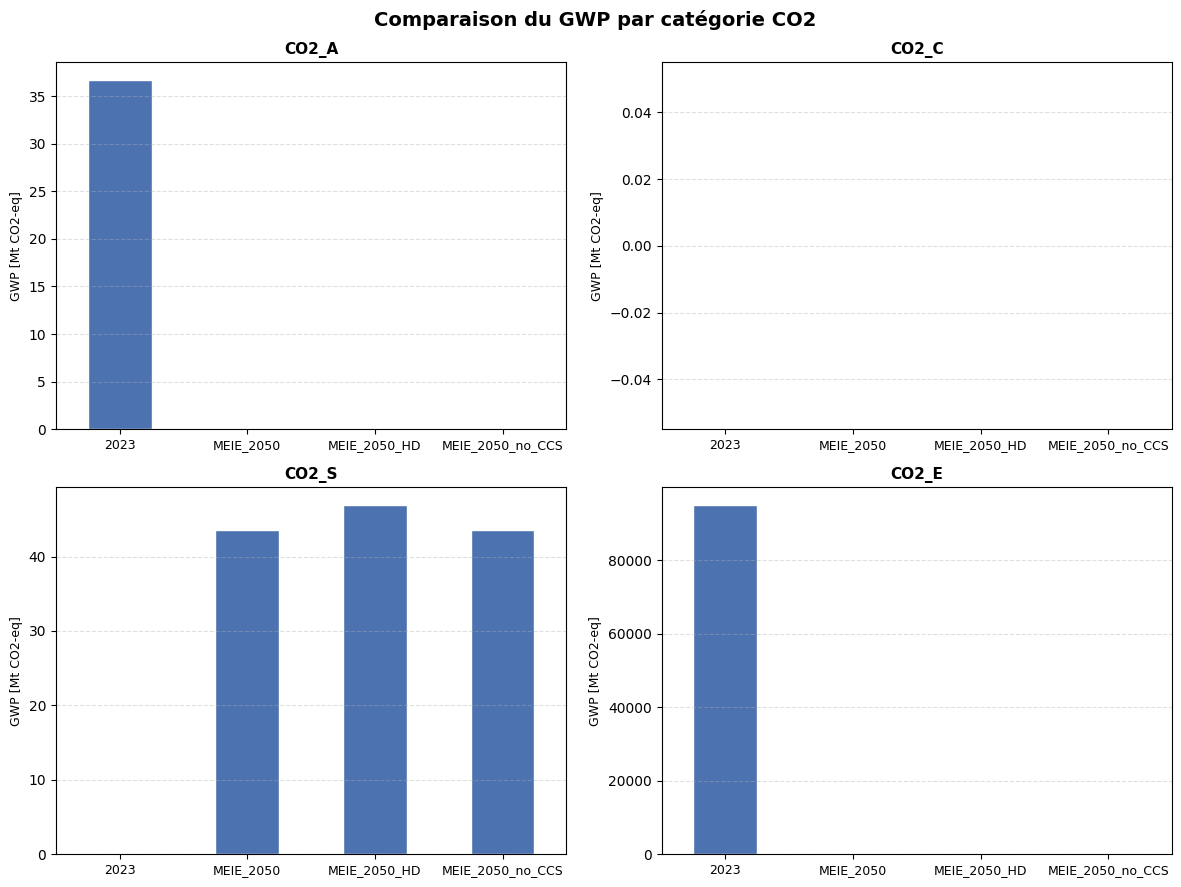


=== Données affichées dans le graphique (Mt CO2-eq) ===


,2023,MEIE_2050,MEIE_2050_HD,MEIE_2050_no_CCS
CO2_A,36.708598,0.000000,0.000000,0.000000
CO2_C,0.000000,0.000000,0.000000,0.000000
CO2_S,0.000000,43.614687,46.948883,43.614687
CO2_E,95034.064451,22.230388,22.223288,22.230388


In [30]:
compare_across_scenarios(generate_gwp_by_category, plot_gwp_comparison_subplots)